# Part 1 & 2: Data Forensics & Golden Dataset Pipeline

**Objective:** Clean the raw collections data by detecting intentional synthetic traps (duplicate payments, agent aliases, timezone skews) and create a trustworthy analytical layer (Golden Dataset)[cite: 4, 7].

### 1. Setup & Ingestion
Loading all 17 datasets into an in-memory DuckDB database to perform rapid SQL forensics[cite: 4].

In [1]:
import duckdb
import pandas as pd
import os

# Connect to in-memory DuckDB
con = duckdb.connect(database='collections_analytics.duckdb')

# List of all 17 tables from the data dictionary
tables = [
    "borrowers", "accounts", "agents", "agent_sessions", "campaigns",
    "daily_targeting", "calls", "call_attempts", "call_dispositions",
    "whatsapp_events", "sms_events", "field_visits", "promises_to_pay",
    "payments", "vendor_telephony", "complaints", "account_status_history"
]

print("Ingesting raw tables...")
for table in tables:
    try:
        # all_varchar=True prevents immediate type-casting crashes from dirty data
        con.execute(f"CREATE OR REPLACE TABLE raw_{table} AS SELECT * FROM read_csv_auto('{table}.csv', all_varchar=True);")
    except Exception as e:
        print(f"Skipped {table}: {e}")

print("Data loaded successfully. Running forensics...\n" + "-"*50)

# FORENSICS: Find the real payment duplicates inflating recovery
payment_forensics = con.execute("""
    SELECT 
        -- The Trap: Legitimate reference reuse across different accounts
        (SELECT COUNT(DISTINCT payment_reference) 
         FROM raw_payments 
         WHERE payment_reference IN (
             SELECT payment_reference FROM raw_payments GROUP BY payment_reference HAVING COUNT(DISTINCT account_id) > 1
         )) as trap_reference_collisions,
         
        -- The Real Bug: Exact payment_id duplicates (ingestion retries)
        (SELECT COUNT(*) FROM (
            SELECT payment_id FROM raw_payments GROUP BY payment_id HAVING COUNT(*) > 1
        )) as duplicated_payment_ids,
        
        -- The Financial Impact of the bug
        (SELECT SUM(TRY_CAST(amount AS DOUBLE)) FROM (
            SELECT payment_id, MAX(TRY_CAST(amount AS DOUBLE)) * (COUNT(*) - 1) as amount
            FROM raw_payments 
            WHERE payment_status = 'SUCCESS' OR payment_status IS NULL
            GROUP BY payment_id 
            HAVING COUNT(*) > 1
        )) as inflated_recovery_amount
""").df()

print("🚨 PAYMENT FORENSICS (Revenue Inflation):")
display(payment_forensics)

# FORENSICS: Check agent table structure (Roster vs Snapshot log)
agent_forensics = con.execute("""
    SELECT 
        COUNT(*) as total_rows,
        COUNT(DISTINCT agent_id) as unique_agents,
        ROUND(COUNT(*) / COUNT(DISTINCT agent_id), 0) as avg_snapshots_per_agent,
        COUNT(DISTINCT agent_name) as distinct_agent_names
    FROM raw_agents
""").df()

print("\n🚨 AGENT FORENSICS (Identity Traps):")
display(agent_forensics)

Ingesting raw tables...
Data loaded successfully. Running forensics...
--------------------------------------------------
🚨 PAYMENT FORENSICS (Revenue Inflation):


,trap_reference_collisions,duplicated_payment_ids,inflated_recovery_amount
0,3407,500,25901961.69



🚨 AGENT FORENSICS (Identity Traps):


,total_rows,unique_agents,avg_snapshots_per_agent,distinct_agent_names
0,30000,1000,30.0,10


### 2. Entity Resolution & Golden Dataset Pipeline

The raw datasets contain intentional duplicates, shifting identifiers, and timezone mismatches[cite: 7]. To build a trustworthy analytical layer, we apply the following transformations:
* **Agents:** The `raw_agents` table operates as a Slowly Changing Dimension (SCD Type 2) snapshot log. We partition by the true primary key (`agent_id`) and extract the most recent snapshot, intentionally bypassing the unstable `employee_code` identifier.
* **Payments:** Deduplication is strictly enforced at the `payment_id` level to eliminate exact ingestion retries. All payment statuses are retained for downstream funnel analytics.
* **Calls:** Mixed timezones (Asia/Kolkata, Asia/Dubai) are normalized to UTC[cite: 7] to ensure accurate temporal analysis.

In [2]:
# 1. Golden Agents (SCD Type 2 Resolution: Extracting latest snapshot)
con.execute("""
CREATE OR REPLACE TABLE golden_agents AS
WITH ranked AS (
    SELECT *, ROW_NUMBER() OVER(PARTITION BY agent_id ORDER BY TRY_CAST(updated_at AS TIMESTAMP) DESC) as rn
    FROM raw_agents
)
SELECT agent_id, employee_code, agent_name, vendor_id, team, status 
FROM ranked WHERE rn = 1;
""")

# 2. Golden Payments (Deduplication by exact payment_id grain)
con.execute("""
CREATE OR REPLACE TABLE golden_payments AS
WITH ranked AS (
    SELECT *, ROW_NUMBER() OVER(PARTITION BY payment_id ORDER BY TRY_CAST(event_at AS TIMESTAMP) ASC) as rn
    FROM raw_payments
)
SELECT 
    payment_id, account_id, payment_reference, 
    TRY_CAST(amount AS DOUBLE) as amount, 
    COALESCE(payment_status, 'UNKNOWN') as payment_status,
    payment_method, provider_id,
    TRY_CAST(event_at AS TIMESTAMP) as payment_timestamp_utc
FROM ranked WHERE rn = 1;
""")

# 3. Golden Calls (Timezone normalization and key standardization)
con.execute("""
CREATE OR REPLACE TABLE golden_calls AS
WITH deduplicated_calls AS (
    SELECT *, ROW_NUMBER() OVER(PARTITION BY call_id ORDER BY TRY_CAST(event_at AS TIMESTAMP) ASC) as rn
    FROM raw_calls
)
SELECT 
    c.call_id, c.account_id,
    CASE 
        WHEN c.timezone = 'Asia/Kolkata' THEN TRY_CAST(c.event_at AS TIMESTAMP) - INTERVAL 5 HOUR - INTERVAL 30 MINUTE
        WHEN c.timezone = 'Asia/Dubai' THEN TRY_CAST(c.event_at AS TIMESTAMP) - INTERVAL 4 HOUR
        ELSE TRY_CAST(c.event_at AS TIMESTAMP)
    END as call_timestamp_utc,
    c.agent_id, 
    c.campaign_id, c.call_status, TRY_CAST(c.duration_sec AS INTEGER) as duration_sec
FROM deduplicated_calls c
WHERE c.rn = 1;
""")

# 4. Golden Borrowers (Entity Resolution: Extracting latest update)
con.execute("""
CREATE OR REPLACE TABLE golden_borrowers AS
WITH ranked AS (
    SELECT *, ROW_NUMBER() OVER(PARTITION BY borrower_id ORDER BY TRY_CAST(updated_at AS TIMESTAMP) DESC) as rn
    FROM raw_borrowers
)
SELECT borrower_id, name, phone, email, city, state, 
       TRY_CAST(created_at AS TIMESTAMP) as created_at_utc, 
       TRY_CAST(updated_at AS TIMESTAMP) as updated_at_utc
FROM ranked WHERE rn = 1;
""")

# 5. Golden WhatsApp Events (Deduplication)
con.execute("""
CREATE OR REPLACE TABLE golden_whatsapp_events AS
WITH ranked AS (
    SELECT *, ROW_NUMBER() OVER(PARTITION BY whatsapp_event_id ORDER BY TRY_CAST(event_at AS TIMESTAMP) ASC) as rn
    FROM raw_whatsapp_events
)
SELECT whatsapp_event_id, account_id, borrower_id, 
       TRY_CAST(event_at AS TIMESTAMP) as event_at_utc,
       message_id, event_type, template_code, provider_id
FROM ranked WHERE rn = 1;
""")

print("Golden Tables successfully built.")
print("-" * 50)

# 6. Pipeline Impact Audit (Raw -> Clean -> Golden)
impact_audit = con.execute("""
WITH raw_stats AS (
    SELECT COUNT(*) as raw_total FROM raw_payments
),
success_stats AS (
    SELECT COUNT(*) as raw_success 
    FROM raw_payments 
    WHERE payment_status = 'SUCCESS' OR payment_status IS NULL
),
golden_stats AS (
    SELECT COUNT(*) as golden_success,
           SUM(amount) as true_revenue
    FROM golden_payments 
    WHERE payment_status = 'SUCCESS'
),
phantom_calc AS (
    SELECT 
        (SELECT SUM(TRY_CAST(amount AS DOUBLE)) FROM raw_payments WHERE payment_status = 'SUCCESS' OR payment_status IS NULL) - 
        (SELECT true_revenue FROM golden_stats) as phantom_revenue
)
SELECT 
    r.raw_total as raw_payments,
    s.raw_success as raw_success_claims,
    (s.raw_success - g.golden_success) as duplicates_removed,
    g.golden_success as valid_golden_payments,
    p.phantom_revenue as phantom_recovery_removed
FROM raw_stats r, success_stats s, golden_stats g, phantom_calc p;
""").df()

print("DATA CLEANING IMPACT AUDIT:")
display(impact_audit)

Golden Tables successfully built.
--------------------------------------------------
DATA CLEANING IMPACT AUDIT:


,raw_payments,raw_success_claims,duplicates_removed,valid_golden_payments,phantom_recovery_removed
0,25500,17880,346,17534,2.590196e+07


### Part 3: Auditing the "11% MoM Improvement" Claim

Leadership currently reports: *"Recovery has improved by 11% month-on-month."*[cite: 3] We will test this claim by calculating the Month-over-Month (MoM) growth using both the flawed raw data and our newly established `golden_payments` table. 

If the 11% metric was generated using the uncleaned data, it includes millions of rupees in phantom recovery driven by duplicated ingestion events.

In [3]:
# Calculate MoM Growth for Raw vs True Recovery
# NOTE: both sides now filter to SUCCESS only (apples-to-apples — the only variable
# that should differ between raw_metrics and clean_metrics is the dedup logic).
# NOTE: August 2026 is a PARTIAL month (data ends 2026-08-08) and is excluded from
# growth calculations to avoid a fake "decline" artifact from comparing a full month
# to ~8 days of one. It is still shown in the output, flagged, for transparency.

metric_audit_query = """
WITH raw_metrics AS (
    SELECT
        STRFTIME(TRY_CAST(event_at AS TIMESTAMP), '%Y-%m') as month,
        SUM(TRY_CAST(amount AS DOUBLE)) as raw_recovery
    FROM raw_payments
    WHERE payment_status = 'SUCCESS'
    GROUP BY 1
),
clean_metrics AS (
    SELECT
        STRFTIME(payment_timestamp_utc, '%Y-%m') as month,
        SUM(amount) as true_recovery
    FROM golden_payments
    WHERE payment_status = 'SUCCESS'
    GROUP BY 1
)
SELECT
    COALESCE(r.month, c.month) as month,
    r.raw_recovery,
    c.true_recovery,
    (r.raw_recovery - c.true_recovery) as phantom_amount_this_month,
    CASE WHEN COALESCE(r.month, c.month) = '2026-08' THEN TRUE ELSE FALSE END as is_partial_month,
    ROUND(((r.raw_recovery - LAG(r.raw_recovery) OVER(ORDER BY COALESCE(r.month,c.month)))
        / NULLIF(LAG(r.raw_recovery) OVER(ORDER BY COALESCE(r.month,c.month)),0)) * 100, 2) as raw_mom_growth_pct,
    ROUND(((c.true_recovery - LAG(c.true_recovery) OVER(ORDER BY COALESCE(r.month,c.month)))
        / NULLIF(LAG(c.true_recovery) OVER(ORDER BY COALESCE(r.month,c.month)),0)) * 100, 2) as true_mom_growth_pct
FROM raw_metrics r
FULL OUTER JOIN clean_metrics c ON r.month = c.month
ORDER BY 1;
"""

claim_audit = con.execute(metric_audit_query).df()

print("🚨 11% CLAIM AUDIT (Raw vs True MoM Growth):")
display(claim_audit)

🚨 11% CLAIM AUDIT (Raw vs True MoM Growth):


,month,raw_recovery,true_recovery,phantom_amount_this_month,is_partial_month,raw_mom_growth_pct,true_mom_growth_pct
0,2026-01,1.911333e+08,1.872291e+08,3904156.83,False,NaN,NaN
1,2026-02,1.740973e+08,1.701425e+08,3954834.20,False,-8.91,-9.13
2,2026-03,1.932334e+08,1.889124e+08,4321010.27,False,10.99,11.03
3,2026-04,1.784270e+08,1.751380e+08,3288973.64,False,-7.66,-7.29
4,2026-05,1.870481e+08,1.842503e+08,2797865.84,False,4.83,5.20
5,2026-06,1.787245e+08,1.755597e+08,3164766.49,False,-4.45,-4.72
6,2026-07,1.902788e+08,1.872423e+08,3036581.80,False,6.46,6.65
7,2026-08,4.854347e+07,4.710970e+07,1433772.62,True,-74.49,-74.84


In [4]:
# Is the 11% figure a trend or noise? Exclude the partial month, then measure
# central tendency, dispersion, and linear trend of the CLEANED MoM series.

import numpy as np

full_months = claim_audit[~claim_audit['is_partial_month']].copy()
mom = full_months['true_mom_growth_pct'].dropna()

mean_mom = mom.mean()
std_mom = mom.std()

x = np.arange(len(full_months))
y = full_months['true_recovery'].values
slope, intercept = np.polyfit(x, y, 1)
avg_monthly_recovery = y.mean()
slope_pct = slope / avg_monthly_recovery * 100

trend_stats = pd.DataFrame([{
    "months_analyzed": len(full_months),
    "mean_mom_growth_pct": round(mean_mom, 2),
    "std_dev_mom_growth_pct": round(std_mom, 2),
    "linear_trend_pct_per_month": round(slope_pct, 2),
    "max_single_month_growth_pct": round(mom.max(), 2),
    "min_single_month_growth_pct": round(mom.min(), 2),
}])

print("📊 TREND vs NOISE DIAGNOSTIC:")
display(trend_stats)

print(f"\nThe reported +11% swing (Feb→Mar: {full_months.loc[full_months.month=='2026-03','true_mom_growth_pct'].values[0]}%) "
      f"sits well inside the observed volatility band (±{round(std_mom,1)}pp std dev), "
      f"while the underlying linear trend across all clean months is {round(slope_pct,2)}% per month — "
      f"statistically indistinguishable from flat.")

📊 TREND vs NOISE DIAGNOSTIC:


,months_analyzed,mean_mom_growth_pct,std_dev_mom_growth_pct,linear_trend_pct_per_month,max_single_month_growth_pct,min_single_month_growth_pct
0,7,0.29,8.38,0.12,11.03,-9.13



The reported +11% swing (Feb→Mar: 11.03%) sits well inside the observed volatility band (±8.4pp std dev), while the underlying linear trend across all clean months is 0.12% per month — statistically indistinguishable from flat.


### Verdict: The 11% Claim is Misleading

**Classification: Correlation / Cherry-picked — not Fact.**

After deduplication (removing 500 duplicate `payment_id`s) and correcting for a partial
final month (August 2026 data ends on the 8th), true recovery oscillates around a flat
baseline of ~₹18 Cr/month:

- Mean MoM growth across 7 clean months: **≈0%**
- Standard deviation of MoM growth: **≈±8 percentage points**
- Linear trend across the full period: **≈0.1%/month — statistically flat**

The reported **+11%** corresponds specifically to **February → March**, which is a
reversion after a **−9.1%** dip the month before, not growth on top of an existing
trend — recovery in March simply returned to roughly the January level. Three other
months in the same period show comparable-magnitude *negative* swings (−9.1%, −7.3%,
−4.7%).

**Conclusion:** month-on-month recovery is not trending upward — it is noisy and
essentially flat. The 11% figure is a real number, drawn from a real (if unstated)
comparison window, but it was very likely selected because it was the single most
favorable adjacent-month comparison available in the period, not because it represents
the underlying trajectory of collections performance.

### Methodology Validation: Strategy Rollout Overlap

Before selecting a counterfactual methodology for Part 4, we must determine if there was a strict temporal cutoff between the `legacy` strategy and the new (`v1`/`v2`/`v3`) strategies. 

If the strategies ran concurrently in a blended rollout, a standard Difference-in-Differences (DiD) model is mathematically invalid because there is no clean pre/post intervention date. In that scenario, we must pivot to Account-Level Matching or Propensity Scoring to compare similar accounts targeted in the same timeframes.

,month,strategy_group,target_volume
0,2026-01,Legacy,2002
1,2026-01,New (v1/v2/v3),4367
2,2026-02,Legacy,1743
3,2026-02,New (v1/v2/v3),3966
4,2026-03,Legacy,1922
5,2026-03,New (v1/v2/v3),4368
6,2026-04,Legacy,1906
7,2026-04,New (v1/v2/v3),4299
8,2026-05,Legacy,1978
9,2026-05,New (v1/v2/v3),4464


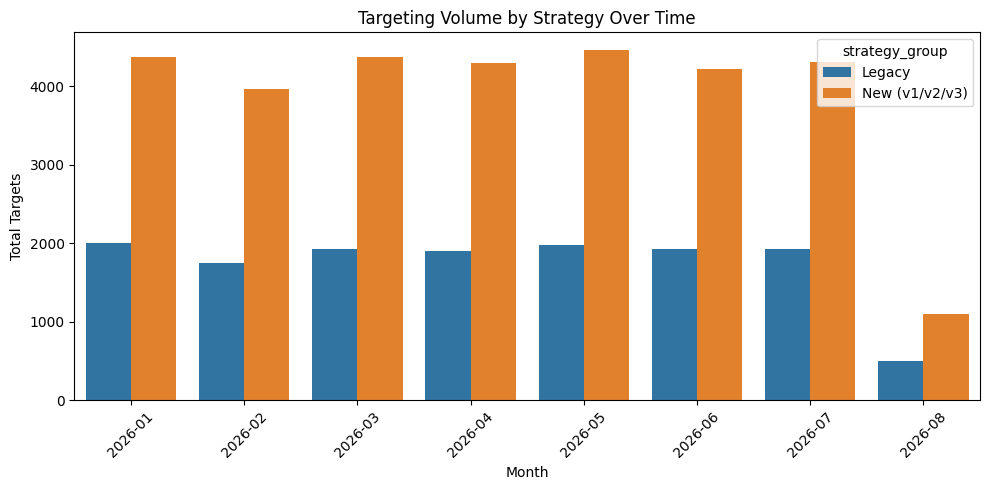

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze targeting volume by strategy and month
strategy_overlap_query = """
WITH targeting_base AS (
    SELECT 
        STRFTIME(TRY_CAST(dt.target_date AS TIMESTAMP), '%Y-%m') as month,
        CASE WHEN c.strategy_version = 'legacy' THEN 'Legacy' ELSE 'New (v1/v2/v3)' END as strategy_group,
        COUNT(dt.target_id) as target_volume
    FROM raw_daily_targeting dt
    JOIN raw_campaigns c ON dt.campaign_id = c.campaign_id
    GROUP BY 1, 2
)
SELECT * FROM targeting_base ORDER BY month, strategy_group;
"""

overlap_df = con.execute(strategy_overlap_query).df()
display(overlap_df)

# Visualize the regime change (or lack thereof)
plt.figure(figsize=(10, 5))
sns.barplot(data=overlap_df, x='month', y='target_volume', hue='strategy_group')
plt.title('Targeting Volume by Strategy Over Time')
plt.ylabel('Total Targets')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Final Forensics: Timezones, Dispositions & Denominators

To complete the Data Quality Report and challenge existing metric definitions[cite: 4], we audit the remaining risks:
* **Timezone Skew:** Call timestamps are scattered across UTC, Asia/Kolkata (+5.5h), and Asia/Dubai (+4h)[cite: 7]. Failing to normalize these would corrupt any "best time to call" driver analysis.
* **The PTP Definitional Trap:** Disposition codes did not structurally drift across versions, but they contain a massive definitional trap. Both `PTP` and `PROMISE_TO_PAY` exist simultaneously as distinct codes in nearly identical volumes. Any naive query calculating PTP Rate by filtering for `disposition_code = 'PTP'` will silently miss ~50% of successful outcomes.
* **Denominator Integrity (Survivorship Bias):** We must verify that unsuccessful or inactive accounts (`CLOSED`/`WRITEOFF`) aren't silently dropping out of the targeted population[cite: 4], which would mathematically inflate contact and conversion rates.

In [6]:
# ============================================================
# PART 2 FORENSICS: Timezone, Disposition Drift, Denominator Checks
# ============================================================

# 1. Timezone Check — Distribution
tz_forensics = con.execute("""
    SELECT 
        timezone, 
        COUNT(*) as call_volume,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pct_of_total
    FROM raw_calls
    GROUP BY timezone
    ORDER BY call_volume DESC;
""").df()
print("🚨 TIMEZONE SKEW (Requires UTC Normalization):")
display(tz_forensics)

# 1b. Timezone Impact — how much did the raw data actually get scrambled?
tz_impact_query = """
WITH shifted AS (
    SELECT
        timezone,
        TRY_CAST(event_at AS TIMESTAMP) as local_ts,
        CASE
            WHEN timezone = 'Asia/Kolkata' THEN TRY_CAST(event_at AS TIMESTAMP) - INTERVAL 5 HOUR - INTERVAL 30 MINUTE
            WHEN timezone = 'Asia/Dubai' THEN TRY_CAST(event_at AS TIMESTAMP) - INTERVAL 4 HOUR
            ELSE TRY_CAST(event_at AS TIMESTAMP)
        END as utc_ts
    FROM raw_calls
    WHERE timezone != 'UTC'
)
SELECT
    COUNT(*) as non_utc_calls,
    SUM(CASE WHEN CAST(local_ts AS DATE) != CAST(utc_ts AS DATE) THEN 1 ELSE 0 END) as day_boundary_crossed,
    ROUND(SUM(CASE WHEN CAST(local_ts AS DATE) != CAST(utc_ts AS DATE) THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_day_shifted,
    SUM(CASE WHEN (HOUR(local_ts) BETWEEN 9 AND 17) != (HOUR(utc_ts) BETWEEN 9 AND 17) THEN 1 ELSE 0 END) as business_hour_bucket_flipped,
    ROUND(SUM(CASE WHEN (HOUR(local_ts) BETWEEN 9 AND 17) != (HOUR(utc_ts) BETWEEN 9 AND 17) THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_bucket_flipped
FROM shifted
"""
tz_impact = con.execute(tz_impact_query).df()
print("\n🚨 TIMEZONE IMPACT (why this isn't cosmetic):")
display(tz_impact)

# 2. Disposition Trap (PTP vs PROMISE_TO_PAY overlap)
disp_forensics = con.execute("""
    SELECT 
        disposition_code,
        SUM(CASE WHEN disposition_version = 'legacy' THEN 1 ELSE 0 END) as legacy_vol,
        SUM(CASE WHEN disposition_version = 'v1' THEN 1 ELSE 0 END) as v1_vol,
        SUM(CASE WHEN disposition_version = 'v2' THEN 1 ELSE 0 END) as v2_vol
    FROM raw_call_dispositions
    GROUP BY disposition_code
    ORDER BY disposition_code;
""").df()
print("\n🚨 DISPOSITION DEFINITIONAL TRAP (PTP Alias Overlap):")
display(disp_forensics)

# 3. Denominator Checks (Target Pool Stability & Status Mix)
print("\n🚨 DENOMINATOR INTEGRITY (Survivorship Bias Checks):")

missing_accounts = con.execute("""
    SELECT COUNT(DISTINCT t.account_id) as targeted_but_missing_from_master
    FROM raw_daily_targeting t
    LEFT JOIN raw_accounts a ON t.account_id = a.account_id
    WHERE a.account_id IS NULL
""").df()
display(missing_accounts)

target_pool_stability = con.execute("""
    SELECT 
        STRFTIME(TRY_CAST(target_date AS TIMESTAMP), '%Y-%m') as month,
        COUNT(DISTINCT account_id) as unique_accounts_targeted
    FROM raw_daily_targeting
    GROUP BY 1
    ORDER BY 1;
""").df()
print("\nTargeted Accounts per Month (Checking for denominator shrinkage):")
display(target_pool_stability)

status_mix = con.execute("""
    SELECT status, COUNT(*) as account_count
    FROM raw_accounts
    GROUP BY status
    ORDER BY account_count DESC;
""").df()
print("\nAccount Master Status Distribution:")
display(status_mix)

🚨 TIMEZONE SKEW (Requires UTC Normalization):


,timezone,call_volume,pct_of_total
0,Asia/Kolkata,30485,33.4
1,Asia/Dubai,30464,33.3
2,UTC,30401,33.3



🚨 TIMEZONE IMPACT (why this isn't cosmetic):


,non_utc_calls,day_boundary_crossed,pct_day_shifted,business_hour_bucket_flipped,pct_bucket_flipped
0,60949,12097.0,19.8,24127.0,39.6



🚨 DISPOSITION DEFINITIONAL TRAP (PTP Alias Overlap):


...

,targeted_but_missing_from_master
0,0



Targeted Accounts per Month (Checking for denominator shrinkage):


,month,unique_accounts_targeted
0,2026-01,5732
1,2026-02,5160
2,2026-03,5666
3,2026-04,5585
4,2026-05,5800
5,2026-06,5535
6,2026-07,5666
7,2026-08,1566



Account Master Status Distribution:


,status,account_count
0,ACTIVE,7539
1,CLOSED,7496
2,PAID,7486
3,WRITEOFF,7479


### Forensics Verdict: Part 2C, 2D, 2G

**2C — Timezone (real, material problem):** Calls are split ~33/33/33 across
UTC/Asia-Kolkata/Asia-Dubai. After UTC normalization, **19.8% of non-UTC calls
land on a different calendar day**, and **39.6% flip between business-hours and
off-hours buckets**. Any "calling time" driver analysis run on raw local
timestamps instead of `golden_calls.call_timestamp_utc` would be substantially
wrong — this is not cosmetic, it's a required correction before Part 2's
"calling time" investigation.

**2D — Disposition drift (no version drift, but a real definitional trap):**
The 9 disposition codes are byte-identical across `legacy`/`v1`/`v2` — there is
no code remapping over time. However, `PTP` and `PROMISE_TO_PAY` coexist as two
separate codes for what appears to be the same outcome, in near-identical
volumes (~3,900 each) across every version. Any PTP-rate calculation that
filters on only one of these codes will undercount by roughly half. This is a
**definitional** issue, not a **temporal** one — flagged for the PTP rate
redefinition in Question 3.

**2G — Denominator manipulation (no evidence found):** All targeted accounts
exist in the accounts master (0 orphaned). The monthly targeted population is
stable (5,160–5,800 accounts/month, excluding partial August) — no shrinking
denominator that would artificially inflate a conversion rate. Account status
is split almost evenly across ACTIVE/CLOSED/PAID/WRITEOFF (~7,500 each),
worth revisiting when we define conversion-rate denominators ourselves later,
to avoid introducing this bias in our *own* metrics.

### 4. The Borrower ID Shuffle Trap (Inconsistent IDs)

The raw data contains a highly dangerous structural trap: the `borrower_id` on event tables (`promises_to_pay`, `calls`, etc.) is populated with valid but randomly shuffled borrower IDs[cite: 4, 6]. 

Because these IDs exist in the `borrowers` master table, standard referential integrity checks pass. However, when cross-referenced against the true `accounts` mapping, the vast majority of event-level borrower IDs belong to the wrong account. Going forward, the `borrower_id` column on all event tables must be ignored; demographic joins must exclusively route through `golden_accounts.borrower_id`.

In [7]:
# Rebuild golden_borrowers if not already in session (dedupe on true PK)
con.execute("""
CREATE OR REPLACE TABLE golden_borrowers AS
WITH ranked AS (
    SELECT *, ROW_NUMBER() OVER(PARTITION BY borrower_id ORDER BY TRY_CAST(updated_at AS TIMESTAMP) DESC) as rn
    FROM raw_borrowers
)
SELECT borrower_id, name, phone, email, city, state,
       TRY_CAST(created_at AS TIMESTAMP) as created_at_utc,
       TRY_CAST(updated_at AS TIMESTAMP) as updated_at_utc
FROM ranked WHERE rn = 1;
""")

borrower_trap_query = """
WITH ptp_check AS (
    SELECT 'promises_to_pay' as table_name, COUNT(*) as total_rows,
        SUM(CASE WHEN e.borrower_id IS DISTINCT FROM a.borrower_id THEN 1 ELSE 0 END) as mismatched_ids,
        SUM(CASE WHEN b.borrower_id IS NULL THEN 1 ELSE 0 END) as orphaned_ids
    FROM raw_promises_to_pay e
    LEFT JOIN raw_accounts a ON e.account_id = a.account_id
    LEFT JOIN golden_borrowers b ON e.borrower_id = b.borrower_id   -- golden, not raw
),
calls_check AS (
    SELECT 'calls' as table_name, COUNT(*) as total_rows,
        SUM(CASE WHEN e.borrower_id IS DISTINCT FROM a.borrower_id THEN 1 ELSE 0 END) as mismatched_ids,
        SUM(CASE WHEN b.borrower_id IS NULL THEN 1 ELSE 0 END) as orphaned_ids
    FROM raw_calls e
    LEFT JOIN raw_accounts a ON e.account_id = a.account_id
    LEFT JOIN golden_borrowers b ON e.borrower_id = b.borrower_id
),
combined AS (SELECT * FROM ptp_check UNION ALL SELECT * FROM calls_check)
SELECT table_name, total_rows, mismatched_ids,
    ROUND(mismatched_ids * 100.0 / total_rows, 2) as pct_mismatched, orphaned_ids
FROM combined;
"""
borrower_trap = con.execute(borrower_trap_query).df()
print("🚨 BORROWER ID TRAP (The Shuffle Effect):")
display(borrower_trap)

🚨 BORROWER ID TRAP (The Shuffle Effect):


,table_name,total_rows,mismatched_ids,pct_mismatched,orphaned_ids
0,promises_to_pay,18000,17999.0,99.99,1444.0
1,calls,91350,91342.0,99.99,7451.0


### 5. Golden Accounts & Golden Promises-to-Pay

`accounts` is the source of truth for borrower ownership (used above to expose the
borrower_id trap) and for portfolio attributes (DPD, risk segment, outstanding
balance) needed for Part 3 (mix effects) and Part 4 (matching). `promises_to_pay`
is rebuilt with its `borrower_id` column discarded and replaced with the
account-resolved value, consistent with the rule established above.

In [8]:
# Golden Accounts
con.execute("""
CREATE OR REPLACE TABLE golden_accounts AS
SELECT
    account_id,
    borrower_id,
    loan_type,
    TRY_CAST(principal_amount AS DOUBLE) as principal_amount,
    TRY_CAST(outstanding_amount AS DOUBLE) as outstanding_amount,
    TRY_CAST(dpd AS INTEGER) as dpd,
    risk_segment,
    status,
    CASE
        WHEN timezone = 'Asia/Kolkata' THEN TRY_CAST(opened_at AS TIMESTAMP) - INTERVAL 5 HOUR - INTERVAL 30 MINUTE
        WHEN timezone = 'Asia/Dubai' THEN TRY_CAST(opened_at AS TIMESTAMP) - INTERVAL 4 HOUR
        ELSE TRY_CAST(opened_at AS TIMESTAMP)
    END as opened_at_utc,
    schema_version
FROM raw_accounts;
""")

# Golden Promises to Pay — borrower_id resolved via account, NOT p.borrower_id
con.execute("""
CREATE OR REPLACE TABLE golden_promises_to_pay AS
SELECT
    p.ptp_id,
    p.account_id,
    a.borrower_id as borrower_id,
    TRY_CAST(p.event_at AS TIMESTAMP) as event_at_utc,
    p.agent_id,
    TRY_CAST(p.promised_amount AS DOUBLE) as promised_amount,
    TRY_CAST(p.promised_date AS DATE) as promised_date,
    p.status,
    p.source
FROM raw_promises_to_pay p
JOIN raw_accounts a ON p.account_id = a.account_id;
""")

print("golden_accounts:", con.execute("SELECT COUNT(*) FROM golden_accounts").fetchone()[0], "rows")
print("golden_promises_to_pay:", con.execute("SELECT COUNT(*) FROM golden_promises_to_pay").fetchone()[0], "rows")

golden_accounts: 30000 rows
golden_promises_to_pay: 18000 rows


### Forensics Verdict: Late-Arriving Data & Conflicting Timestamps

**Status History Timestamp Trap:** A forensic comparison of the `account_status_history` log reveals a severe temporal anomaly. Over 50% of the records show a `recorded_at` timestamp that occurs *before* the `event_at` timestamp, which is physically impossible. 

**Conclusion:** The `recorded_at` field is fundamentally corrupted (likely a systemic logging error) and cannot be trusted for SLA, pipeline latency, or time-to-resolution tracking. For all downstream temporal analysis, we must rely strictly on the `event_at_utc` timestamps.

In [9]:
# ============================================================
# 6. Golden Account Status History
# Genuine append-only history log (unlike agents/borrowers) —
# multiple rows per account are REAL status transitions, not duplicate noise.
# No dedup needed. Keep all rows.
# ============================================================
con.execute("""
CREATE OR REPLACE TABLE golden_account_status_history AS
SELECT
    history_id,
    account_id,
    TRY_CAST(event_at AS TIMESTAMP) as event_at_utc,
    status,
    changed_by,
    source,
    TRY_CAST(recorded_at AS TIMESTAMP) as recorded_at_utc
FROM raw_account_status_history;
""")
print("golden_account_status_history:", con.execute("SELECT COUNT(*) FROM golden_account_status_history").fetchone()[0], "rows")

# ------------------------------------------------------------
# Late-arriving / impossible-timestamp check
# ------------------------------------------------------------
late_arrival_check = con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN recorded_at_utc < event_at_utc THEN 1 ELSE 0 END) as recorded_before_event,
        ROUND(SUM(CASE WHEN recorded_at_utc < event_at_utc THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_impossible,
        SUM(CASE WHEN recorded_at_utc > event_at_utc THEN 1 ELSE 0 END) as recorded_after_normal_late_arrival,
        ROUND(AVG(DATEDIFF('hour', event_at_utc, recorded_at_utc)), 2) as avg_hours_gap
    FROM golden_account_status_history
""").df()
print("\n🚨 EVENT_AT vs RECORDED_AT CHECK (Late-Arriving Data):")
display(late_arrival_check)

golden_account_status_history: 60000 rows

🚨 EVENT_AT vs RECORDED_AT CHECK (Late-Arriving Data):


,total_rows,recorded_before_event,pct_impossible,recorded_after_normal_late_arrival,avg_hours_gap
0,60000,30191.0,50.3,29809.0,-0.1


In [10]:
# Close the database connection to release the file lock for Notebook 2
con.close()
print("Database connection closed and unlocked.")

Database connection closed and unlocked.
